In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread("../data/raw/ball_1_top.jpeg",1)
img1 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)



In [ ]:
lower_green = np.array([20,20,20])
higher_green = np.array([85,255,255])

bg_mask = cv2.inRange(hsv, lowerb=lower_green, upperb=higher_green)
mask = cv2.bitwise_not(bg_mask)

# final = cv2.bitwise_and(img1, img1, mask=mask)



In [54]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (75,75))

snapped_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

In [55]:
contours , hierarchy = cv2.findContours(snapped_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

black_canvas = np.zeros_like(snapped_mask)

if contours:
    largest_contours = max(contours , key=cv2.contourArea)

    cv2.drawContours(black_canvas, [largest_contours], -1 ,255 ,-1)

final = cv2.bitwise_and(img1, img1, mask=black_canvas)

In [56]:
images = [img1, hsv, bg_mask, mask ,snapped_mask,black_canvas,final]
titles = ["original","hsv","bg mask","mask","snapped_mask","clean_mask", "final"]

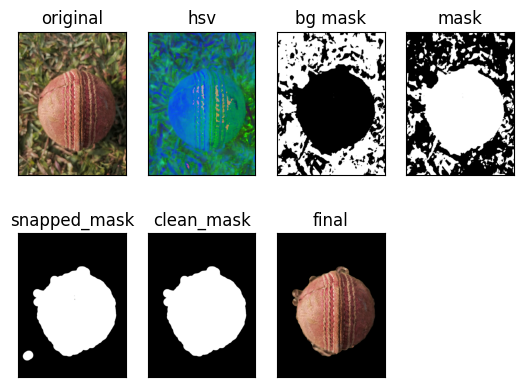

In [57]:
for i in range(len(images)):
    plt.subplot(2,4,(i+1))
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
    
    if len(images[i].shape)== 2:
        plt.imshow(images[i],"grey")
    else:
        plt.imshow(images[i])

plt.savefig("after_adding_contours.png")
plt.show()


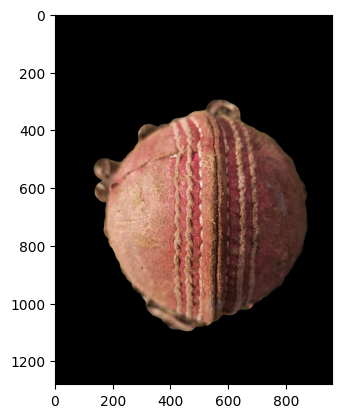

In [58]:
plt.imshow(final)
plt.show()